In [ ]:

# STEP 1 : IMPORT LIBRARIES


# Pandas is used to read and manipulate datasets
import pandas as pd

# Numpy is used for numerical calculations
import numpy as np

# Matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# Seaborn is used for attractive statistical graphs
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Libraries

# Split dataset into training and testing
from sklearn.model_selection import train_test_split

# Convert text values into numeric values
from sklearn.preprocessing import LabelEncoder

# Scale numerical data
from sklearn.preprocessing import StandardScaler

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:

# STEP 2 : LOAD DATASET


# Upload your CSV file to Google Colab
from google.colab import files

uploaded = files.upload()

# Read CSV file
df = pd.read_csv("AI Smart Waste Management.csv")

# Show first 5 rows
df.head()

Saving AI Smart Waste Management.csv to AI Smart Waste Management (3).csv


,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year,Collection Priority
0,Mumbai,Plastic,6610.0,68.0,11191.0,9.0,Composting,3056.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium
1,Mumbai,Organic,1181.0,56.0,11191.0,5.0,Composting,2778.0,12.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Low
2,Mumbai,E-Waste,8162.0,53.0,11191.0,8.0,Incineration,3390.0,13.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium
3,Mumbai,Construction,8929.0,56.0,11191.0,5.0,Landfill,1498.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,High
4,Mumbai,Hazardous,5032.0,44.0,11191.0,7.0,Recycling,2221.0,16.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium


In [ ]:
#Explore Dataset
# Display first 10 rows
df.head(10)

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year,Collection Priority
0,Mumbai,Plastic,6610.0,68.0,11191.0,9.0,Composting,3056.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium
1,Mumbai,Organic,1181.0,56.0,11191.0,5.0,Composting,2778.0,12.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Low
2,Mumbai,E-Waste,8162.0,53.0,11191.0,8.0,Incineration,3390.0,13.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium
3,Mumbai,Construction,8929.0,56.0,11191.0,5.0,Landfill,1498.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,High
4,Mumbai,Hazardous,5032.0,44.0,11191.0,7.0,Recycling,2221.0,16.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0,Medium
5,Mumbai,Plastic,7456.0,73.0,11191.0,9.0,Landfill,3195.0,6.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2020.0,Medium
6,Mumbai,Organic,7118.0,37.0,11191.0,6.0,Composting,3686.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2020.0,Medium
7,Mumbai,E-Waste,9189.0,57.0,11191.0,10.0,Landfill,1791.0,12.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2020.0,Medium
8,Mumbai,Construction,8609.0,48.0,11191.0,8.0,Incineration,1681.0,20.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2020.0,Medium
9,Mumbai,Hazardous,6632.0,71.0,11191.0,6.0,Incineration,2311.0,12.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2020.0,Medium


In [ ]:
# Display last 10 rows
df.tail(10)

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year,Collection Priority
39990,Jaipur,Plastic,4913.815130,52.654342,2323.849111,5.707469,Composting,3801.978660,11.152827,Jaipur Landfill,"11.6909, 94.4267",69834.96035,1925.365347,Medium
39991,Mumbai,Organic,3306.026669,76.383193,11099.786870,5.911258,Incineration,2464.111514,9.740757,Mumbai Landfill,"22.4265, 77.4931",45747.05935,1990.992007,Medium
39992,Coimbatore,E-Waste,6980.589577,50.967447,11672.334380,5.945158,Landfill,5096.570800,10.106176,Coimbatore Landfill,"31.9729, 76.5516",103352.93530,2075.190555,Medium
39993,Madurai,Plastic,8723.003404,55.562175,20066.441750,9.334477,Landfill,1395.003436,11.501439,Madurai Landfill,"13.1884, 95.8263",50300.99705,1959.186178,Medium
39994,Kanpur,Hazardous,6719.796924,52.189518,18767.151240,10.146815,Incineration,1089.721879,8.578573,Kanpur Landfill,"13.0189, 89.182",23381.07393,2041.081223,Medium
39995,Jaipur,E-Waste,9304.463213,48.913764,2320.350222,9.826605,Incineration,1887.809498,7.153717,Jaipur Landfill,"11.6909, 94.4267",71242.22794,2060.657511,Medium
39996,Pune,Construction,514.439837,33.815462,12400.299350,4.838313,Recycling,1974.916776,5.806270,Pune Landfill,"28.7237, 84.2278",48521.28595,2096.589150,Medium
39997,Jodhpur,Hazardous,5670.693624,65.479308,6447.823239,8.701228,Incineration,4578.065445,15.406099,Jodhpur Landfill,"8.9824, 77.0472",43588.68019,2105.763064,Low
39998,Chennai,Hazardous,2996.083971,44.973185,21189.776200,8.073550,Composting,852.447288,18.310417,Chennai Landfill,"29.4633, 80.8873",68079.61353,1995.349990,Medium
39999,Varanasi,Construction,541.081526,60.986350,8270.504640,6.236980,Landfill,2764.158208,8.827061,Varanasi Landfill,"35.156, 83.0516",81576.21634,2001.067495,Low


In [ ]:
# Check number of rows and columns

print("Dataset Shape :", df.shape)

Dataset Shape : (40000, 14)


In [ ]:
# Show all column names

print(df.columns)

Index(['City/District', 'Waste Type', 'Waste Generated (Tons/Day)',
       'Recycling Rate (%)', 'Population Density (People/km²)',
       'Municipal Efficiency Score (1-10)', 'Disposal Method',
       'Cost of Waste Management (₹/Ton)', 'Awareness Campaigns Count',
       'Landfill Name', 'Landfill Location (Lat, Long)',
       'Landfill Capacity (Tons)', 'Year', 'Collection Priority'],
      dtype='object')


In [ ]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   City/District                      40000 non-null  object 
 1   Waste Type                         40000 non-null  object 
 2   Waste Generated (Tons/Day)         40000 non-null  float64
 3   Recycling Rate (%)                 40000 non-null  float64
 4   Population Density (People/km²)    40000 non-null  float64
 5   Municipal Efficiency Score (1-10)  40000 non-null  float64
 6   Disposal Method                    40000 non-null  object 
 7   Cost of Waste Management (₹/Ton)   40000 non-null  float64
 8   Awareness Campaigns Count          40000 non-null  float64
 9   Landfill Name                      40000 non-null  object 
 10  Landfill Location (Lat, Long)      40000 non-null  object 
 11  Landfill Capacity (Tons)           40000 non-null  flo

In [ ]:
# Check data type of every column

df.dtypes

,0
City/District,object
Waste Type,object
Waste Generated (Tons/Day),float64
Recycling Rate (%),float64
Population Density (People/km²),float64
Municipal Efficiency Score (1-10),float64
Disposal Method,object
Cost of Waste Management (₹/Ton),float64
Awareness Campaigns Count,float64
Landfill Name,object


In [ ]:
# Summary of numerical columns

df.describe()

,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Capacity (Tons),Year
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,5258.743742,57.034098,13497.570785,7.415385,2782.765630,9.907970,58858.996721,2020.619698
std,2795.878323,16.216297,6648.527174,1.733684,1278.738204,6.068396,19462.020271,57.810850
min,486.233429,28.504057,2218.312070,4.750058,480.395782,0.000000,21556.258450,1918.088150
25%,2868.046995,43.000000,7749.584350,5.930011,1644.810956,4.788219,46169.319413,1970.987351
50%,5256.977893,56.510748,12719.528610,7.272671,2853.439960,10.417923,60468.369500,2021.000000
75%,7750.365975,71.000000,18997.986467,8.950399,3861.760485,15.037369,71735.896745,2070.095826
max,10449.294230,89.241917,25227.885140,10.499952,5247.199682,20.997040,103577.270200,2124.144108


In [ ]:
# Count missing values in each column

df.isnull().sum()

,0
City/District,0
Waste Type,0
Waste Generated (Tons/Day),0
Recycling Rate (%),0
Population Density (People/km²),0
Municipal Efficiency Score (1-10),0
Disposal Method,0
Cost of Waste Management (₹/Ton),0
Awareness Campaigns Count,0
Landfill Name,0


In [ ]:
# Count duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# Count unique values in every column

df.nunique()

,0
City/District,34
Waste Type,5
Waste Generated (Tons/Day),39957
Recycling Rate (%),39206
Population Density (People/km²),39183
Municipal Efficiency Score (1-10),39156
Disposal Method,4
Cost of Waste Management (₹/Ton),39930
Awareness Campaigns Count,37002
Landfill Name,34


In [ ]:
# Display counts of target classes

df["Collection Priority"].value_counts()

,count
Collection Priority,
Medium,24143
Low,11302
High,4555


In [ ]:

# STEP 4 : DATA CLEANING


# Display missing values in each column
print("Missing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Remove duplicate rows (if any)
# ------------------------------------------

print("\nDuplicate Rows Before:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())

# ------------------------------------------
# Fill Missing Values
# ------------------------------------------

# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

# Select categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Fill numerical missing values using mean
for column in numerical_columns:
    df[column].fillna(df[column].mean(), inplace=True)

# Fill categorical missing values using mode
for column in categorical_columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Check again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Missing Values:
City/District                        0
Waste Type                           0
Waste Generated (Tons/Day)           0
Recycling Rate (%)                   0
Population Density (People/km²)      0
Municipal Efficiency Score (1-10)    0
Disposal Method                      0
Cost of Waste Management (₹/Ton)     0
Awareness Campaigns Count            0
Landfill Name                        0
Landfill Location (Lat, Long)        0
Landfill Capacity (Tons)             0
Year                                 0
Collection Priority                  0
dtype: int64

Duplicate Rows Before: 0
Duplicate Rows After: 0

Missing Values After Cleaning:
City/District                        0
Waste Type                           0
Waste Generated (Tons/Day)           0
Recycling Rate (%)                   0
Population Density (People/km²)      0
Municipal Efficiency Score (1-10)    0
Disposal Method                      0
Cost of Waste Management (₹/Ton)     0
Awareness Campaigns Count      

In [ ]:
#Dataset shap
print(df.shape)

(40000, 14)


In [ ]:
df.describe()

,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Capacity (Tons),Year
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,5258.743742,57.034098,13497.570785,7.415385,2782.765630,9.907970,58858.996721,2020.619698
std,2795.878323,16.216297,6648.527174,1.733684,1278.738204,6.068396,19462.020271,57.810850
min,486.233429,28.504057,2218.312070,4.750058,480.395782,0.000000,21556.258450,1918.088150
25%,2868.046995,43.000000,7749.584350,5.930011,1644.810956,4.788219,46169.319413,1970.987351
50%,5256.977893,56.510748,12719.528610,7.272671,2853.439960,10.417923,60468.369500,2021.000000
75%,7750.365975,71.000000,18997.986467,8.950399,3861.760485,15.037369,71735.896745,2070.095826
max,10449.294230,89.241917,25227.885140,10.499952,5247.199682,20.997040,103577.270200,2124.144108


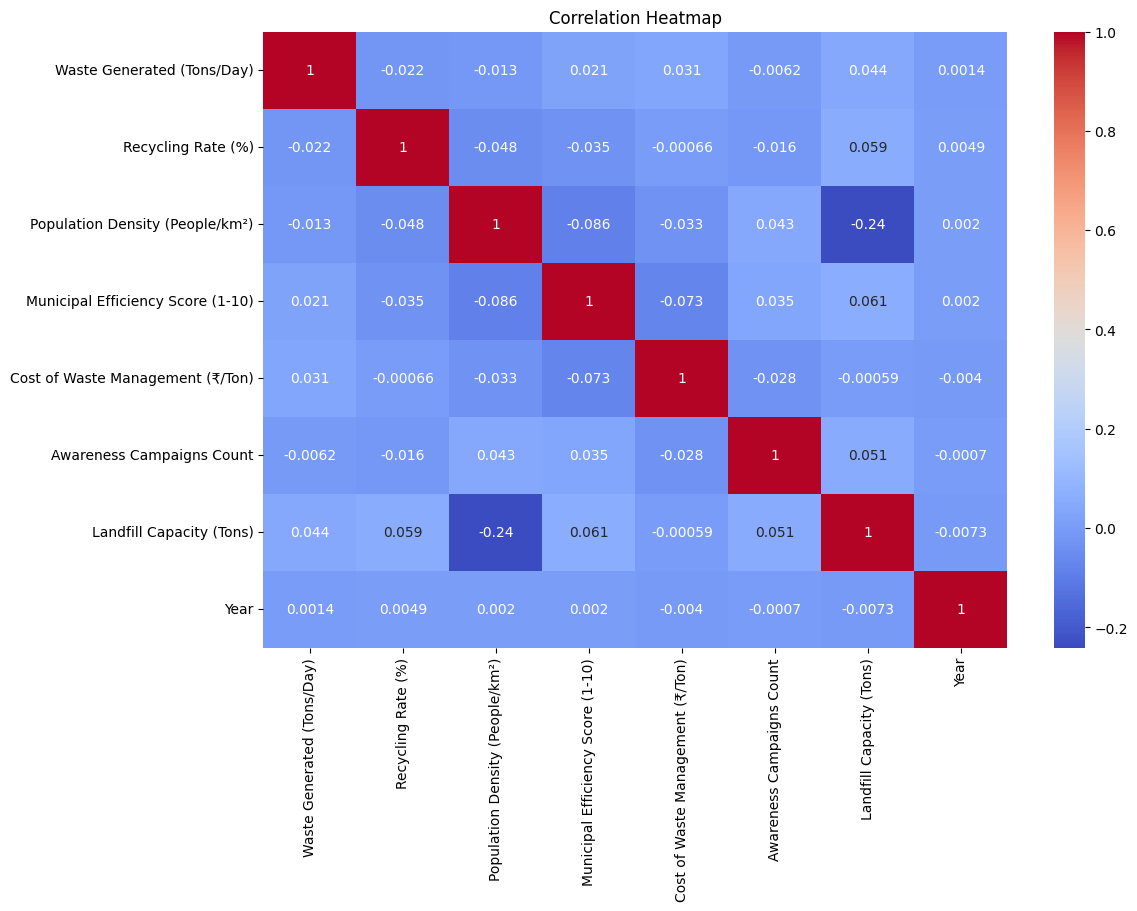

In [ ]:

# Correlation Heatmap
#Blue → Negative correlation
#Red → Positive correlation
#Near 1 → Strong relationship
#Near 0 → Weak relationship

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

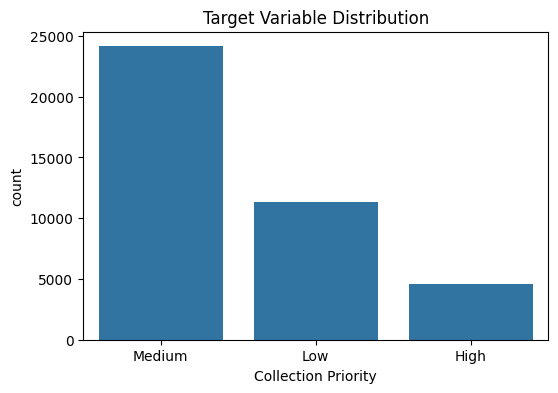

In [ ]:
# Count Plot of Target Variable
plt.figure(figsize=(6,4))

sns.countplot(x="Collection Priority", data=df)

plt.title("Target Variable Distribution")
plt.show()

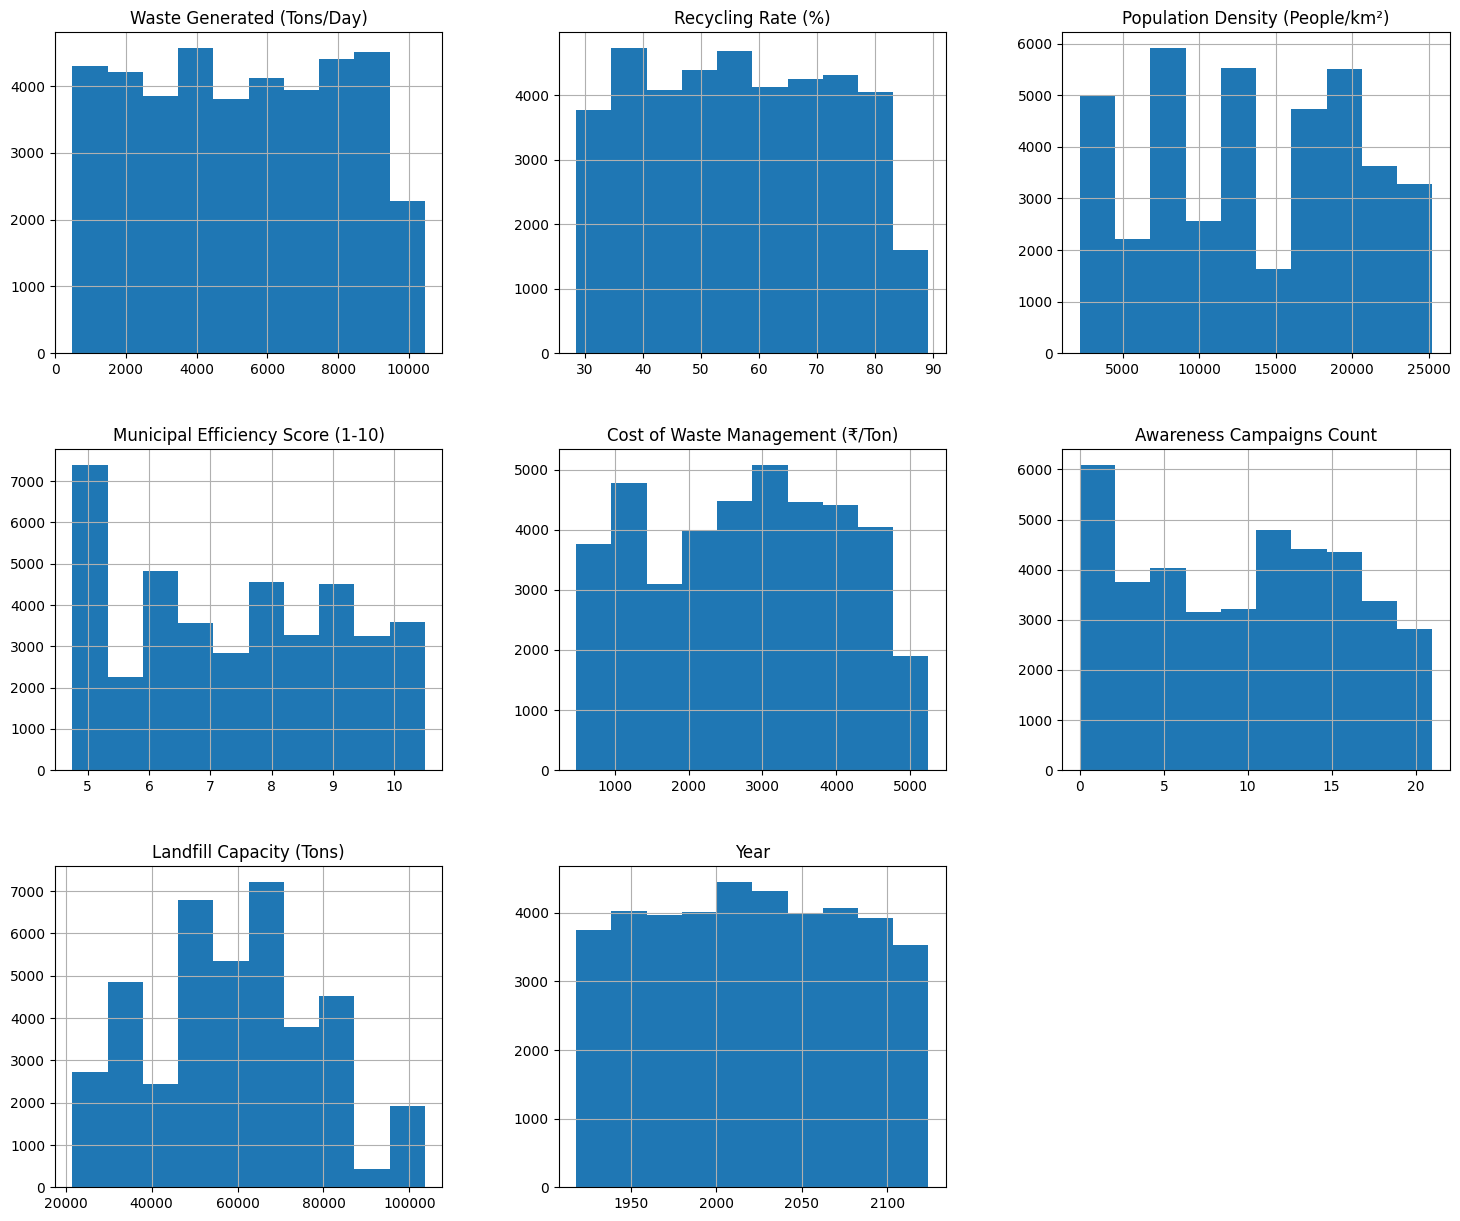

In [ ]:
# Plot histogram for all numerical columns

df.hist(figsize=(18,15))

plt.show()

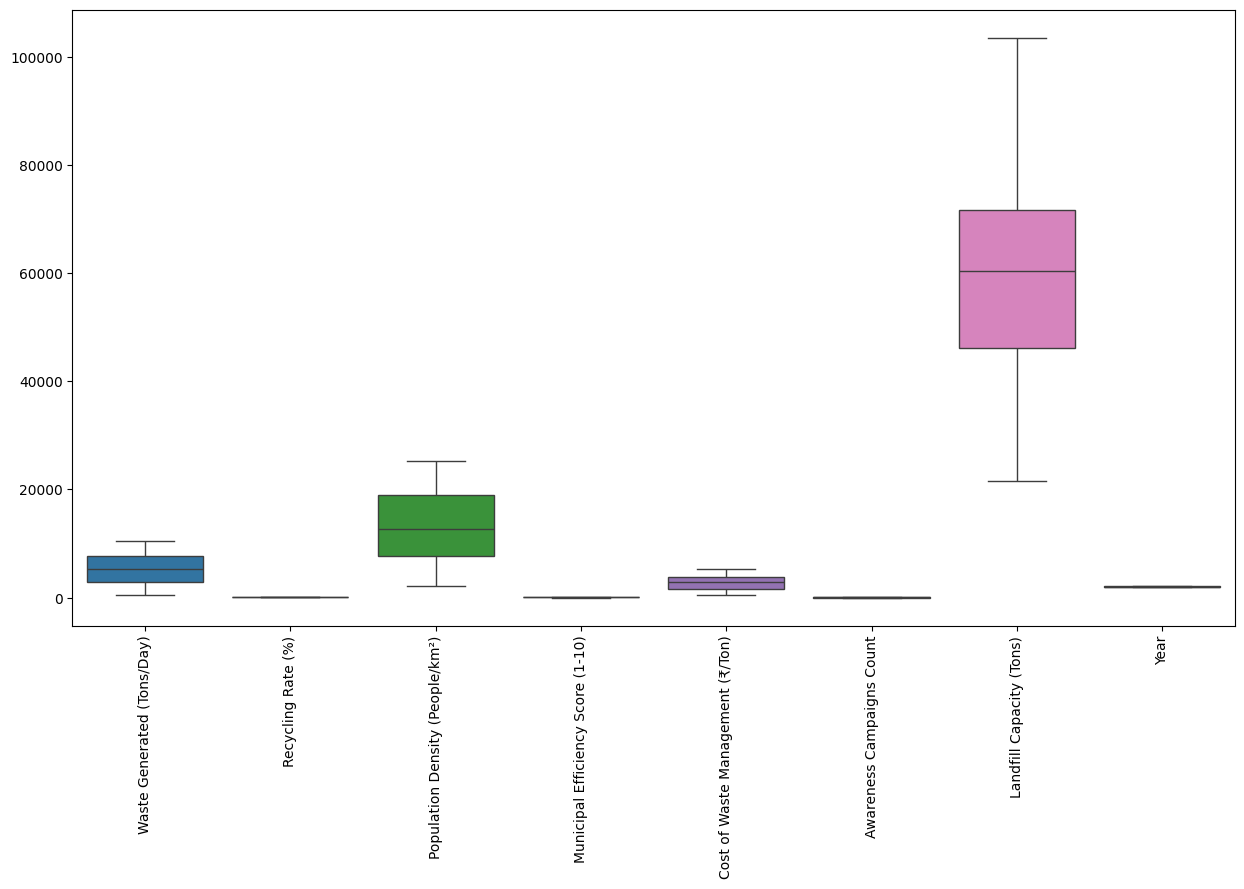

In [ ]:
#Box plot
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))

plt.xticks(rotation=90)

plt.show()

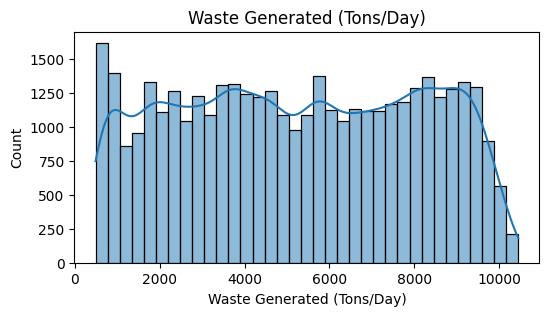

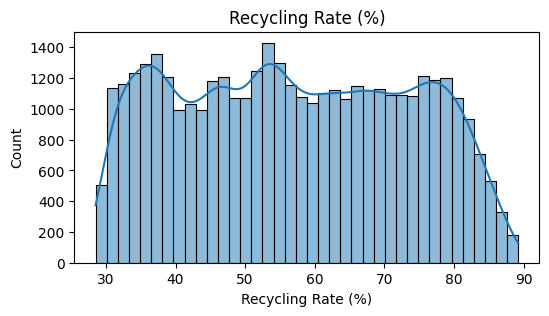

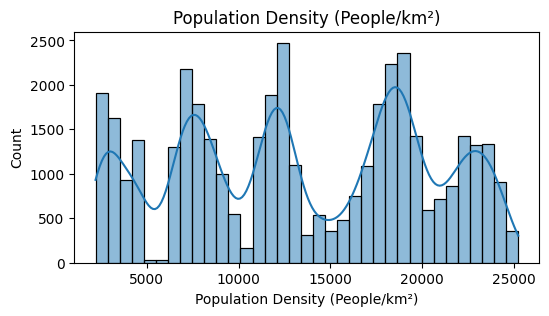

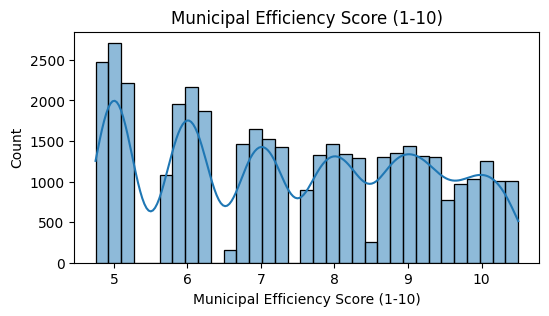

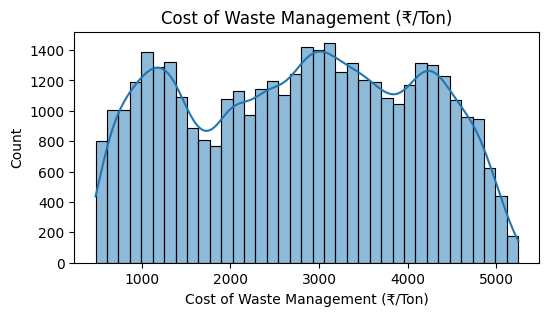

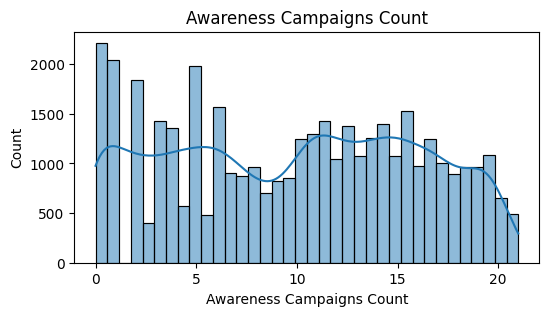

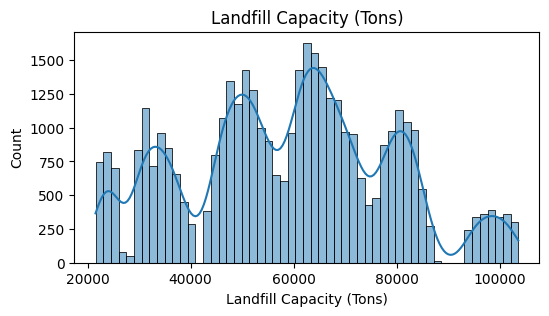

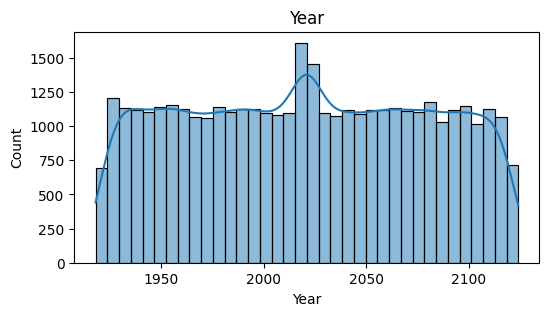

In [ ]:
# Plot distribution of all numerical columns

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.histplot(df[column], kde=True)

    plt.title(column)

    plt.show()

In [ ]:

# STEP 6 : FEATURE SELECTION


# Features (Input)

X = df.drop("Collection Priority", axis=1)

# Target (Output)

y = df["Collection Priority"]

In [ ]:
#check shape
print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (40000, 13)
Target Shape : (40000,)


In [ ]:
#display features
X.head()

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year
0,Mumbai,Plastic,6610.0,68.0,11191.0,9.0,Composting,3056.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0
1,Mumbai,Organic,1181.0,56.0,11191.0,5.0,Composting,2778.0,12.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0
2,Mumbai,E-Waste,8162.0,53.0,11191.0,8.0,Incineration,3390.0,13.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0
3,Mumbai,Construction,8929.0,56.0,11191.0,5.0,Landfill,1498.0,14.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0
4,Mumbai,Hazardous,5032.0,44.0,11191.0,7.0,Recycling,2221.0,16.0,Mumbai Landfill,"22.4265, 77.4931",45575.0,2019.0


In [ ]:
#display Target
y.head()

,Collection Priority
0,Medium
1,Low
2,Medium
3,High
4,Medium


In [ ]:

# STEP 7 : ENCODE CATEGORICAL VARIABLES


# Create LabelEncoder object
label_encoder = LabelEncoder()

# Find all categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

# Convert each categorical column into numbers
for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

# Convert target column if it contains text values
if y.dtype == 'object':
    y = label_encoder.fit_transform(y)

print("\nEncoding Completed Successfully!")

Categorical Columns:
Index(['City/District', 'Waste Type', 'Disposal Method', 'Landfill Name',
       'Landfill Location (Lat, Long)'],
      dtype='object')

Encoding Completed Successfully!


In [ ]:
# Display first 5 rows
X.head()

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year
0,22,4,6610.0,68.0,11191.0,9.0,0,3056.0,14.0,22,18,45575.0,2019.0
1,22,3,1181.0,56.0,11191.0,5.0,0,2778.0,12.0,22,18,45575.0,2019.0
2,22,1,8162.0,53.0,11191.0,8.0,1,3390.0,13.0,22,18,45575.0,2019.0
3,22,0,8929.0,56.0,11191.0,5.0,2,1498.0,14.0,22,18,45575.0,2019.0
4,22,2,5032.0,44.0,11191.0,7.0,3,2221.0,16.0,22,18,45575.0,2019.0


In [ ]:

# STEP 8 : FEATURE SCALING

# Create StandardScaler object
scaler = StandardScaler()

# Scale all features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [ ]:
#check the scaled data
X_scaled.head()

,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year
0,0.563902,1.414836,0.483309,0.676236,-0.346934,0.914028,-1.350183,0.213678,0.674327,0.563902,0.154051,-0.682569,-0.028018
1,0.563902,0.709332,-1.458502,-0.063770,-0.346934,-1.393227,-1.350183,-0.003727,0.344746,0.563902,0.154051,-0.682569,-0.028018
2,0.563902,-0.701677,1.038419,-0.248771,-0.346934,0.337214,-0.453141,0.474876,0.509536,0.563902,0.154051,-0.682569,-0.028018
3,0.563902,-1.407181,1.312755,-0.063770,-0.346934,-1.393227,0.443901,-1.004726,0.674327,0.563902,0.154051,-0.682569,-0.028018
4,0.563902,0.003827,-0.081100,-0.803775,-0.346934,-0.239600,1.340943,-0.439318,1.003907,0.563902,0.154051,-0.682569,-0.028018


In [ ]:
StandardScaler()

StandardScaler()

In [ ]:

# STEP 9 : TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (32000, 13)
Testing Features  : (8000, 13)
Training Target   : (32000,)
Testing Target    : (8000,)


In [ ]:

# STEP 10 : LOGISTIC REGRESSION


# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

# Predict on testing data
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [ ]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_log)

print("Accuracy :", accuracy)

Accuracy : 0.99475


In [ ]:
precision = precision_score(
    y_test,
    y_pred_log,
    average='weighted'
)

print("Precision :", precision)

Precision : 0.9947535984361265


In [ ]:
recall = recall_score(
    y_test,
    y_pred_log,
    average='weighted'
)

print("Recall :", recall)

Recall : 0.99475


In [ ]:
f1 = f1_score(
    y_test,
    y_pred_log,
    average='weighted'
)

print("F1 Score :", f1)

F1 Score : 0.9947494350576339


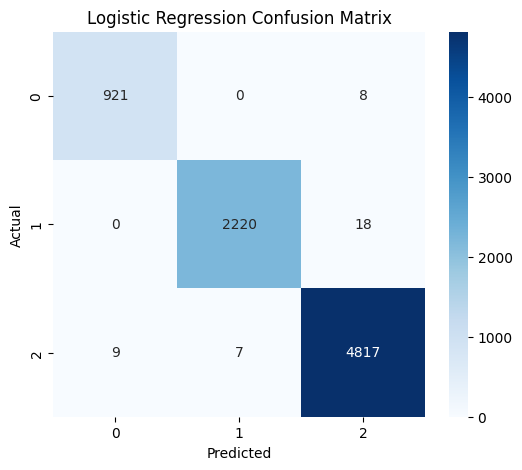

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       929
           1       1.00      0.99      0.99      2238
           2       0.99      1.00      1.00      4833

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



In [ ]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_log
})

prediction_df.head(10)

,Actual,Predicted
0,2,2
1,0,0
2,2,2
3,2,2
4,1,1
5,1,1
6,0,0
7,1,1
8,1,1
9,2,2


In [ ]:

# STEP 11 : DECISION TREE CLASSIFIER


# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict using testing data
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [ ]:
# Calculate Accuracy

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.964875


In [ ]:
dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree Precision :", dt_precision)

Decision Tree Precision : 0.9649514076140215


In [ ]:
dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree Recall :", dt_recall)

Decision Tree Recall : 0.964875


In [ ]:
dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree F1 Score :", dt_f1)

Decision Tree F1 Score : 0.9648950912152107


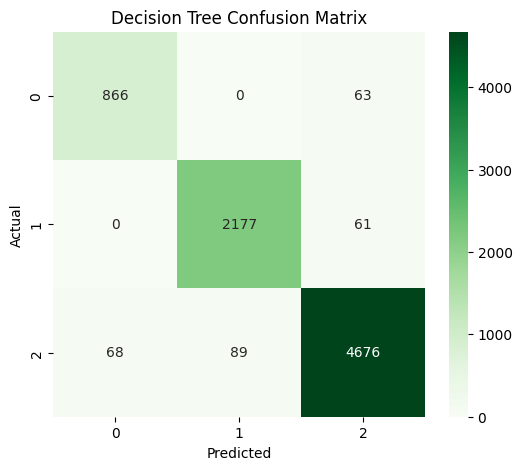

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       929
           1       0.96      0.97      0.97      2238
           2       0.97      0.97      0.97      4833

    accuracy                           0.96      8000
   macro avg       0.95      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000



In [ ]:

# STEP 12 : RANDOM FOREST


# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.977375


In [ ]:
rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest Recall :", rf_recall)

Random Forest Recall : 0.977375


In [ ]:
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest F1 Score :", rf_f1)

Random Forest F1 Score : 0.977377576668028


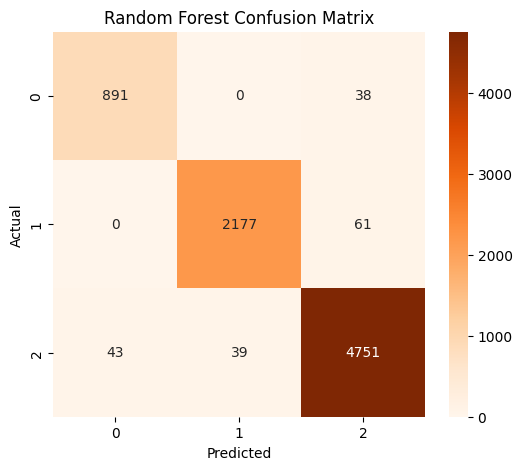

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       929
           1       0.98      0.97      0.98      2238
           2       0.98      0.98      0.98      4833

    accuracy                           0.98      8000
   macro avg       0.97      0.97      0.97      8000
weighted avg       0.98      0.98      0.98      8000



In [ ]:
# ==========================================
# STEP 13 : KNN CLASSIFIER
# ==========================================

# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.9645


In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.9645


In [ ]:
knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

print("KNN Recall :", knn_recall)

KNN Recall : 0.9645


In [ ]:
knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

print("KNN F1 Score :", knn_f1)

KNN F1 Score : 0.964542933490985


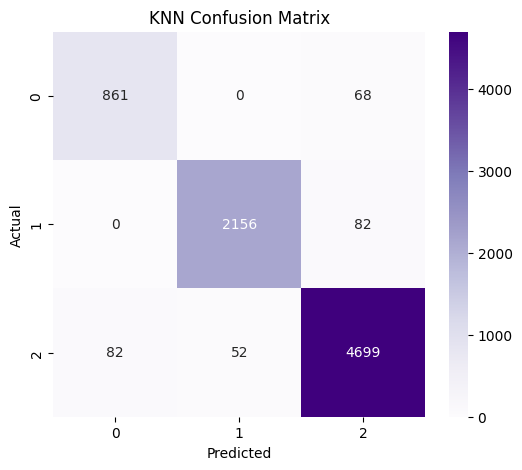

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       929
           1       0.98      0.96      0.97      2238
           2       0.97      0.97      0.97      4833

    accuracy                           0.96      8000
   macro avg       0.95      0.95      0.95      8000
weighted avg       0.96      0.96      0.96      8000

